# Glioblastoma Xenium To AnnData

This notebook assembles multiple Xenium samples from `/Volumes/processing2/glioblastoma-xenium` into sparse `AnnData` objects and one combined KaroSpace-ready `.h5ad`.

By default it auto-discovers all valid sample directories under the root.

Workflow:

1. Discover and validate sample directories.
2. Load per-sample cell metadata and experiment metadata.
3. Read each sparse HDF5 cell-feature matrix.
4. Keep `Gene Expression` features by default.
5. Build one sparse `AnnData` per sample with `obsm["spatial"]`.
6. Concatenate the selected samples into one combined sparse `AnnData`.
7. Optionally write per-sample and combined `.h5ad` files.


In [ ]:
from __future__ import annotations

import json
import os
from pathlib import Path

os.environ.setdefault("KMP_WARNINGS", "0")
os.environ.setdefault("NUMBA_DISABLE_JIT", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import anndata as ad
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD

ad.settings.allow_write_nullable_strings = True

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path("/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling")
ROOT = PROJECT_ROOT
DATA_ROOT = Path("/Volumes/processing2/glioblastoma-xenium")
# Set to None to auto-discover every valid sample directory under DATA_ROOT.
# Or set to an explicit list such as ["SNU21", "SNU33"].
SAMPLE_IDS = None

OUTPUT_DIR = ROOT / "data" / "processed" / "glioblastoma-xenium"
PER_SAMPLE_OUTPUT_DIR = OUTPUT_DIR / "per_sample"
COMBINED_OUTPUT_PATH = OUTPUT_DIR / "glioblastoma-xenium-combined.h5ad"
ANALYSIS_OUTPUT_PATH = OUTPUT_DIR / "glioblastoma-xenium-combined-analysis.h5ad"

INCLUDE_CONTROL_FEATURES = False
WRITE_PER_SAMPLE_OUTPUTS = True
WRITE_COMBINED_OUTPUT = True
RELOAD_COMBINED_OUTPUT = True
WRITE_ANALYSIS_OUTPUT = True
RUN_PREPROCESSING = True
MIN_COUNTS = 20
MIN_GENES = 5
TARGET_SUM = 10_000.0
N_SVD_COMPONENTS = 20
N_CLUSTERS = 3  0

def sample_paths(sample_id: str) -> dict[str, Path]:
    data_dir = DATA_ROOT / sample_id
    return {
        "data_dir": data_dir,
        "cells": data_dir / "cells.csv.gz",
        "matrix_h5": data_dir / "cell_feature_matrix.h5",
        "experiment": data_dir / "experiment.xenium",
        "metrics": data_dir / "metrics_summary.csv",
        "major_annotation": data_dir / "summarymajor_celltype_annotation.csv",
        "minor_annotation": data_dir / "summaryminor_celltype_annotation.csv",
    }


available_samples = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("._"))
valid_samples = []
invalid_samples = {}
for sample_id in available_samples:
    paths = sample_paths(sample_id)
    required = ["cells", "matrix_h5", "experiment"]
    missing = [k for k in required if not paths[k].exists()]
    if missing:
        invalid_samples[sample_id] = missing
    else:
        valid_samples.append(sample_id)

selected_samples = valid_samples if SAMPLE_IDS is None else SAMPLE_IDS
missing_requested_samples = [s for s in selected_samples if s not in available_samples]
if missing_requested_samples:
    raise FileNotFoundError(f"missing requested samples: {missing_requested_samples}")

invalid_requested_samples = {s: invalid_samples[s] for s in selected_samples if s in invalid_samples}
if invalid_requested_samples:
    raise FileNotFoundError(f"requested samples missing required files: {invalid_requested_samples}")

ROOT, DATA_ROOT.exists(), selected_samples, valid_samples, invalid_samples, COMBINED_OUTPUT_PATH, ANALYSIS_OUTPUT_PATH


(PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling'),
 True,
 ['S1', 'S2', 'S5', 'S6', 'SNU21', 'SNU33'],
 ['S1', 'S2', 'S5', 'S6', 'SNU21', 'SNU33'],
 {},
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/glioblastoma-xenium-combined.h5ad'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/glioblastoma-xenium-combined-analysis.h5ad'))

## Discover sample inputs

Each sample directory is expected to contain:

- `cells.csv.gz`
- `cell_feature_matrix.h5`
- `experiment.xenium`

Some sidecar files such as `metrics_summary.csv` and the annotation CSVs may be missing for a subset of samples and are treated as optional.


In [99]:
sample_inputs = {}
for sample_id in selected_samples:
    paths = sample_paths(sample_id)
    cells = pd.read_csv(paths["cells"])
    experiment = json.load(open(paths["experiment"]))
    metrics = pd.read_csv(paths["metrics"]) if paths["metrics"].exists() else None
    sample_inputs[sample_id] = {
        "paths": paths,
        "cells": cells,
        "experiment": experiment,
        "metrics": metrics,
    }
    print(
        sample_id,
        "cells:", cells.shape,
        "region:", experiment.get("region_name"),
        "panel:", experiment.get("panel_name"),
        "matrix exists:", paths["matrix_h5"].exists(),
        "metrics exists:", paths["metrics"].exists(),
    )

sample_inputs[selected_samples[0]]["cells"].head()


S1 cells: (95794, 11) region: 21_083_1 panel: hBrain_348g matrix exists: True metrics exists: True
S2 cells: (66067, 11) region: 21_083_2 panel: hBrain_348g matrix exists: True metrics exists: True
S5 cells: (29959, 11) region: 21_083_5 panel: hBrain_348g matrix exists: True metrics exists: True
S6 cells: (71779, 11) region: 21_028_6 panel: hBrain_348g matrix exists: True metrics exists: True
SNU21 cells: (651590, 11) region: TA3859A panel: hBrain_348g matrix exists: True metrics exists: False
SNU33 cells: (266796, 11) region: 21-109 panel: hBrain_348g matrix exists: True metrics exists: True


,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area
0,aaaaenhl-1,1058.086670,15.583479,6,0,0,0,0,6,819.947217,5.915469
1,aaabafci-1,1095.969971,849.029480,202,0,0,0,0,202,675.853618,31.925470
2,aaabkgdi-1,1106.786377,834.867310,201,0,0,0,0,201,335.601262,37.344220
3,aaaejplh-1,1122.369507,840.919983,286,0,0,0,0,286,580.077209,48.001095
4,aaafabdf-1,1120.727417,864.147949,100,0,0,0,0,100,445.105172,22.081407


In [100]:
matrix_summaries = {}
for sample_id in selected_samples:
    matrix_path = sample_inputs[sample_id]["paths"]["matrix_h5"]
    with h5py.File(matrix_path, "r") as f:
        matrix_summaries[sample_id] = {
            "shape": tuple(int(x) for x in f["matrix/shape"][:]),
            "feature_types": sorted(set(x.decode() for x in f["matrix/features/feature_type"][:])),
            "first_barcodes": [x.decode() for x in f["matrix/barcodes"][:5]],
            "first_features": [x.decode() for x in f["matrix/features/name"][:10]],
        }

for sample_id, summary in matrix_summaries.items():
    print(sample_id, summary["shape"], summary["feature_types"])

matrix_summaries


S1 (541, 95794) ['Gene Expression', 'Negative Control Codeword', 'Negative Control Probe', 'Unassigned Codeword']
S2 (541, 66067) ['Gene Expression', 'Negative Control Codeword', 'Negative Control Probe', 'Unassigned Codeword']
S5 (541, 29959) ['Gene Expression', 'Negative Control Codeword', 'Negative Control Probe', 'Unassigned Codeword']
S6 (541, 71779) ['Gene Expression', 'Negative Control Codeword', 'Negative Control Probe', 'Unassigned Codeword']
SNU21 (541, 651590) ['Gene Expression', 'Negative Control Codeword', 'Negative Control Probe', 'Unassigned Codeword']
SNU33 (541, 266796) ['Gene Expression', 'Negative Control Codeword', 'Negative Control Probe', 'Unassigned Codeword']


{'S1': {'shape': (541, 95794),
  'feature_types': ['Gene Expression',
   'Negative Control Codeword',
   'Negative Control Probe',
   'Unassigned Codeword'],
  'first_barcodes': ['aaaaenhl-1',
   'aaabafci-1',
   'aaabkgdi-1',
   'aaaejplh-1',
   'aaafabdf-1'],
  'first_features': ['A2M',
   'ABCG2',
   'ACTA2',
   'ACTG2',
   'ADAM12',
   'ADGRE5',
   'ADGRL4',
   'ADGRV1',
   'ADIRF',
   'AIF1']},
 'S2': {'shape': (541, 66067),
  'feature_types': ['Gene Expression',
   'Negative Control Codeword',
   'Negative Control Probe',
   'Unassigned Codeword'],
  'first_barcodes': ['aaaaeilm-1',
   'aaaaodbg-1',
   'aaaapima-1',
   'aaabkfpl-1',
   'aaabkmho-1'],
  'first_features': ['A2M',
   'ABCG2',
   'ACTA2',
   'ACTG2',
   'ADAM12',
   'ADGRE5',
   'ADGRL4',
   'ADGRV1',
   'ADIRF',
   'AIF1']},
 'S5': {'shape': (541, 29959),
  'feature_types': ['Gene Expression',
   'Negative Control Codeword',
   'Negative Control Probe',
   'Unassigned Codeword'],
  'first_barcodes': ['aaabdcfn-1',
 

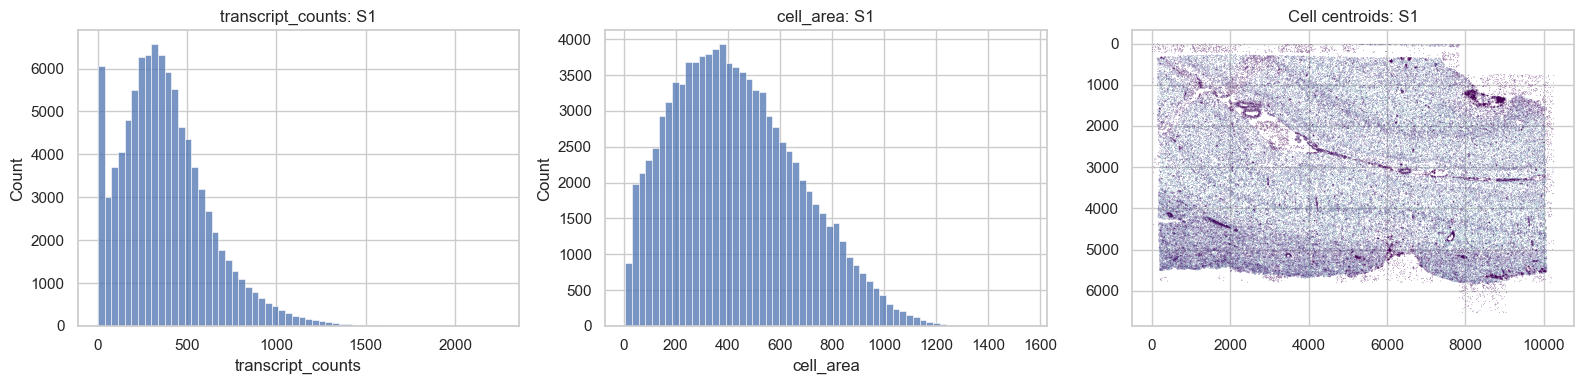

In [101]:
preview_sample = selected_samples[0]
preview_cells = sample_inputs[preview_sample]["cells"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(preview_cells["transcript_counts"], bins=60, ax=axes[0])
axes[0].set_title(f"transcript_counts: {preview_sample}")

sns.histplot(preview_cells["cell_area"], bins=60, ax=axes[1])
axes[1].set_title(f"cell_area: {preview_sample}")

axes[2].scatter(
    preview_cells["x_centroid"],
    preview_cells["y_centroid"],
    s=0.2,
    c=preview_cells["transcript_counts"],
    cmap="viridis",
    linewidths=0,
)
axes[2].set_title(f"Cell centroids: {preview_sample}")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


## Build sparse per-sample `AnnData`

Each sample matrix is loaded as sparse CSC from the 10x HDF5 file and converted to sparse CSR cell-by-feature form. Control features are excluded by default.


In [102]:
def sanitize_obs_for_h5ad(obs_df: pd.DataFrame) -> pd.DataFrame:
    out = obs_df.copy()
    for col in out.columns:
        ser = out[col]
        if isinstance(ser.dtype, pd.CategoricalDtype):
            continue
        if pd.api.types.is_object_dtype(ser) or pd.api.types.is_string_dtype(ser):
            out[col] = ser.astype("string")
    return out


def load_experiment_summary(experiment_obj: dict) -> dict:
    keep = [
        "run_name",
        "region_name",
        "preservation_method",
        "num_cells",
        "transcripts_per_cell",
        "transcripts_per_100um",
        "cassette_name",
        "slide_id",
        "panel_name",
        "panel_organism",
        "panel_tissue_type",
        "panel_num_targets_predesigned",
        "panel_num_targets_custom",
        "pixel_size",
        "analysis_sw_version",
    ]
    return {k: experiment_obj.get(k) for k in keep}


def build_obs(cells_df: pd.DataFrame, experiment_obj: dict, sample_id: str) -> pd.DataFrame:
    obs = cells_df.copy()
    obs["cell_id"] = obs["cell_id"].astype("string")
    obs["cell_id_original"] = obs["cell_id"]
    obs["cell_id"] = (sample_id + "__" + obs["cell_id"].astype(str)).astype("string")

    for col in [
        "transcript_counts",
        "control_probe_counts",
        "control_codeword_counts",
        "unassigned_codeword_counts",
        "deprecated_codeword_counts",
        "total_counts",
    ]:
        obs[col] = pd.to_numeric(obs[col], errors="coerce").astype("Int32")

    for col in ["x_centroid", "y_centroid", "cell_area", "nucleus_area"]:
        obs[col] = pd.to_numeric(obs[col], errors="coerce").astype("float32")

    region_name = experiment_obj.get("region_name", sample_id)
    obs["dataset_id"] = pd.Categorical(["glioblastoma-xenium"] * len(obs))
    obs["sample_id"] = pd.Categorical([sample_id] * len(obs))
    obs["section_id"] = pd.Categorical([f"{sample_id}_{region_name}"] * len(obs))
    obs["run_name"] = pd.Categorical([experiment_obj.get("run_name", "unknown")] * len(obs))
    obs["panel_name"] = pd.Categorical([experiment_obj.get("panel_name", "unknown")] * len(obs))
    obs["preservation_method"] = pd.Categorical([experiment_obj.get("preservation_method", "unknown")] * len(obs))

    obs = sanitize_obs_for_h5ad(obs)
    return obs.set_index("cell_id", drop=False)


def load_sparse_matrix_and_var(path: Path, include_control_features: bool = False) -> tuple[sparse.csr_matrix, pd.DataFrame, pd.Index]:
    with h5py.File(path, "r") as f:
        data = f["matrix/data"][:]
        indices = f["matrix/indices"][:]
        indptr = f["matrix/indptr"][:]
        shape = tuple(int(x) for x in f["matrix/shape"][:])

        barcodes = pd.Index([x.decode() for x in f["matrix/barcodes"][:]], name="cell_id_original")
        feature_ids = np.array([x.decode() for x in f["matrix/features/id"][:]], dtype=object)
        feature_names = np.array([x.decode() for x in f["matrix/features/name"][:]], dtype=object)
        feature_types = np.array([x.decode() for x in f["matrix/features/feature_type"][:]], dtype=object)
        genomes = np.array([x.decode() for x in f["matrix/features/genome"][:]], dtype=object)

    X = sparse.csc_matrix((data, indices, indptr), shape=shape).transpose().tocsr()

    var = pd.DataFrame(
        {
            "feature_id": feature_ids,
            "feature_name": feature_names,
            "feature_type": feature_types,
            "genome": genomes,
        },
        index=pd.Index(feature_names.astype(str), name="gene"),
    )

    if not include_control_features:
        keep = var["feature_type"].eq("Gene Expression").to_numpy()
        X = X[:, keep]
        var = var.loc[keep].copy()

    if not var.index.is_unique:
        seen = {}
        new_index = []
        for gene in var.index.astype(str):
            count = seen.get(gene, 0)
            new_index.append(gene if count == 0 else f"{gene}-{count}")
            seen[gene] = count + 1
        var.index = pd.Index(new_index, name="gene")

    return X, var, barcodes


sample_build = {}
for sample_id in selected_samples:
    cells = sample_inputs[sample_id]["cells"]
    experiment = sample_inputs[sample_id]["experiment"]
    matrix_path = sample_inputs[sample_id]["paths"]["matrix_h5"]

    obs = build_obs(cells, experiment, sample_id)
    X, var, barcodes = load_sparse_matrix_and_var(matrix_path, include_control_features=INCLUDE_CONTROL_FEATURES)

    sample_build[sample_id] = {
        "obs": obs,
        "X": X,
        "var": var,
        "barcodes": barcodes,
    }

    print(sample_id, "obs:", obs.shape, "matrix:", X.shape, "var:", var.shape)


S1 obs: (95794, 18) matrix: (95794, 348) var: (348, 4)
S2 obs: (66067, 18) matrix: (66067, 348) var: (348, 4)
S5 obs: (29959, 18) matrix: (29959, 348) var: (348, 4)
S6 obs: (71779, 18) matrix: (71779, 348) var: (348, 4)
SNU21 obs: (651590, 18) matrix: (651590, 348) var: (348, 4)
SNU33 obs: (266796, 18) matrix: (266796, 348) var: (348, 4)


In [103]:
per_sample_adatas = {}
for sample_id in selected_samples:
    obs = sample_build[sample_id]["obs"]
    X = sample_build[sample_id]["X"]
    var = sample_build[sample_id]["var"]
    barcodes = sample_build[sample_id]["barcodes"]
    experiment = sample_inputs[sample_id]["experiment"]
    metrics = sample_inputs[sample_id]["metrics"]

    obs_lookup = obs.set_index("cell_id_original", drop=False)
    missing_from_obs = barcodes.difference(obs_lookup.index)
    missing_from_matrix = obs_lookup.index.difference(barcodes)
    if len(missing_from_obs) or len(missing_from_matrix):
        raise ValueError(
            f"{sample_id}: barcode mismatch: missing_from_obs={len(missing_from_obs)}, missing_from_matrix={len(missing_from_matrix)}"
        )

    obs_aligned = obs_lookup.reindex(barcodes).copy()
    obs_aligned = obs_aligned.set_index("cell_id", drop=True)
    adata_one = ad.AnnData(X=X, obs=obs_aligned, var=var.copy())
    adata_one.obsm["spatial"] = adata_one.obs[["x_centroid", "y_centroid"]].to_numpy(dtype=np.float32)
    adata_one.uns["experiment"] = load_experiment_summary(experiment)
    if metrics is not None and not metrics.empty:
        adata_one.uns["metrics_summary"] = metrics.iloc[0].to_dict()
    per_sample_adatas[sample_id] = adata_one

adata = ad.concat(
    per_sample_adatas,
    axis=0,
    join="inner",
    merge="same",
    uns_merge="first",
    label="source_sample",
    index_unique=None,
)

adata


AnnData object with n_obs × n_vars = 1181985 × 348
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_id_original', 'dataset_id', 'sample_id', 'section_id', 'run_name', 'panel_name', 'preservation_method', 'source_sample'
    var: 'feature_id', 'feature_name', 'feature_type', 'genome'
    uns: 'experiment', 'metrics_summary'
    obsm: 'spatial'

In [104]:
print("obs x vars:", adata.n_obs, adata.n_vars)
print("X format:", type(adata.X), "nnz:", adata.X.nnz)
print("obsm keys:", list(adata.obsm.keys()))
print("feature types kept:", adata.var["feature_type"].value_counts().to_dict())
print("cells per sample:")
print(adata.obs["sample_id"].value_counts().sort_index())

adata.obs.head()


obs x vars: 1181985 348
X format: <class 'scipy.sparse._csr.csr_matrix'> nnz: 75092510
obsm keys: ['spatial']
feature types kept: {'Gene Expression': 348}
cells per sample:
sample_id
S1        95794
S2        66067
S5        29959
S6        71779
SNU21    651590
SNU33    266796
Name: count, dtype: int64


,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,cell_id_original,dataset_id,sample_id,section_id,run_name,panel_name,preservation_method,source_sample
cell_id,,,,,,,,,,,,,,,,,,
S1__aaaaenhl-1,1058.086670,15.583479,6,0,0,0,0,6,819.947205,5.915469,aaaaenhl-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1
S1__aaabafci-1,1095.969971,849.029480,202,0,0,0,0,202,675.853638,31.925470,aaabafci-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1
S1__aaabkgdi-1,1106.786377,834.867310,201,0,0,0,0,201,335.601257,37.344219,aaabkgdi-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1
S1__aaaejplh-1,1122.369507,840.919983,286,0,0,0,0,286,580.077209,48.001095,aaaejplh-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1
S1__aaafabdf-1,1120.727417,864.147949,100,0,0,0,0,100,445.105164,22.081408,aaafabdf-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1


## Optional annotation tables

The two `summary...celltype_annotation.csv` files are gene-centric reference tables, not per-cell assignments. They are useful for marker interpretation, but they are not merged into `obs`.


In [105]:
annotation_tables = {}
for sample_id in selected_samples:
    paths = sample_inputs[sample_id]["paths"]
    major_annotation = pd.read_csv(paths["major_annotation"]) if paths["major_annotation"].exists() else None
    minor_annotation = pd.read_csv(paths["minor_annotation"]) if paths["minor_annotation"].exists() else None
    annotation_tables[sample_id] = {
        "major": major_annotation,
        "minor": minor_annotation,
    }
    print(
        sample_id,
        "major:", None if major_annotation is None else major_annotation.shape,
        "minor:", None if minor_annotation is None else minor_annotation.shape,
    )

first_major = next((annotation_tables[s]["major"] for s in selected_samples if annotation_tables[s]["major"] is not None), None)
if first_major is not None:
    first_major[["Genes", "Single cell type expression cluster", "Single cell type specificity"]].head()
else:
    print("No major annotation tables available")


S1 major: None minor: None
S2 major: None minor: None
S5 major: None minor: None
S6 major: None minor: None
SNU21 major: None minor: None
SNU33 major: (348, 41) minor: (348, 152)


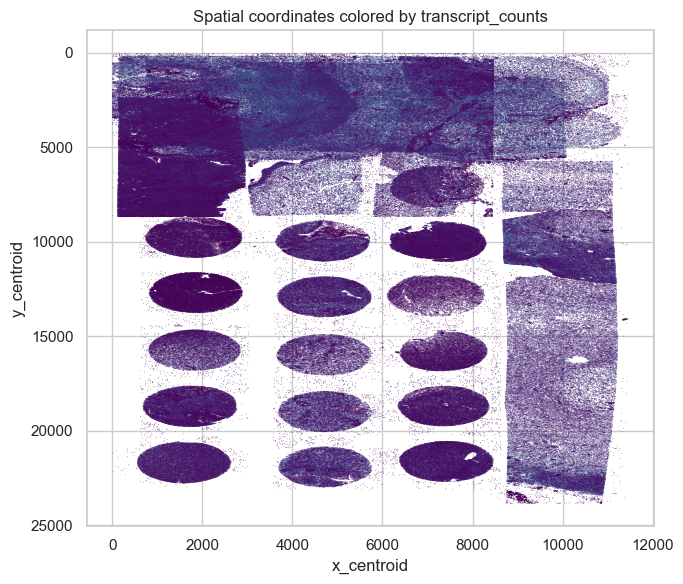

In [106]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    adata.obsm["spatial"][:, 0],
    adata.obsm["spatial"][:, 1],
    s=0.2,
    c=adata.obs["transcript_counts"].astype(float).to_numpy(),
    cmap="viridis",
    linewidths=0,
)
ax.set_title("Spatial coordinates colored by transcript_counts")
ax.set_xlabel("x_centroid")
ax.set_ylabel("y_centroid")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Optional preprocessing and basic clustering

This section avoids a full dense transform:

- filters very low-count cells
- library-size normalizes the sparse count matrix
- applies `log1p` to the sparse nonzero values
- runs `TruncatedSVD`
- runs `MiniBatchKMeans`

It is intended as a fast baseline so you do not have to cluster from scratch with a heavier pipeline first.


In [107]:
def normalize_log1p_csr(X: sparse.spmatrix, target_sum: float = 10_000.0) -> sparse.csr_matrix:
    X = X.tocsr(copy=True).astype(np.float32)
    counts = np.asarray(X.sum(axis=1)).ravel().astype(np.float32)
    counts[counts == 0] = 1.0
    scale = target_sum / counts
    X = sparse.diags(scale) @ X
    X = X.tocsr()
    X.data = np.log1p(X.data)
    return X


if RUN_PREPROCESSING:
    detected_genes = np.asarray((adata.X > 0).sum(axis=1)).ravel()
    total_counts = np.asarray(adata.X.sum(axis=1)).ravel()

    adata.obs["detected_genes"] = detected_genes.astype(np.int32)
    adata.obs["raw_total_counts"] = total_counts.astype(np.float32)

    keep_cells = (adata.obs["raw_total_counts"] >= MIN_COUNTS) & (adata.obs["detected_genes"] >= MIN_GENES)
    analysis_adata = adata[keep_cells].copy()
    print("cells after filtering:", analysis_adata.n_obs, "of", adata.n_obs)

    X_norm = normalize_log1p_csr(analysis_adata.X, target_sum=TARGET_SUM)
    analysis_adata.layers["lognorm"] = X_norm

    n_components = max(2, min(N_SVD_COMPONENTS, analysis_adata.n_vars - 1))
    svd = TruncatedSVD(n_components=n_components, random_state=0)
    X_svd = svd.fit_transform(X_norm)
    analysis_adata.obsm["X_svd"] = X_svd.astype(np.float32)
    analysis_adata.obsm["X_svd_2d"] = X_svd[:, :2].astype(np.float32)

    kmeans = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        random_state=0,
        batch_size=4096,
        n_init=10,
    )
    labels = kmeans.fit_predict(X_svd)
    analysis_adata.obs["kmeans_cluster"] = pd.Categorical(labels.astype(str))

    analysis_adata.uns["preprocessing"] = {
        "min_counts": int(MIN_COUNTS),
        "min_genes": int(MIN_GENES),
        "target_sum": float(TARGET_SUM),
        "n_svd_components": int(n_components),
        "n_clusters": int(N_CLUSTERS),
        "method": "TruncatedSVD + MiniBatchKMeans",
    }

    analysis_adata
else:
    analysis_adata = None
    print("RUN_PREPROCESSING is False")


cells after filtering: 1139726 of 1181985


cluster sizes:
kmeans_cluster
0     29696
1     44446
10    54461
11    28639
12    30984
13    51021
14    29666
15    21430
16    59553
17    20560
18    58556
19    34451
2     38003
20    31023
21    34997
22    40820
23    23653
24    30943
25    33661
26    24949
27    80527
28    26422
29    37125
3     28090
4     51161
5     38544
6     35274
7     28740
8     25431
9     66900
Name: count, dtype: int64


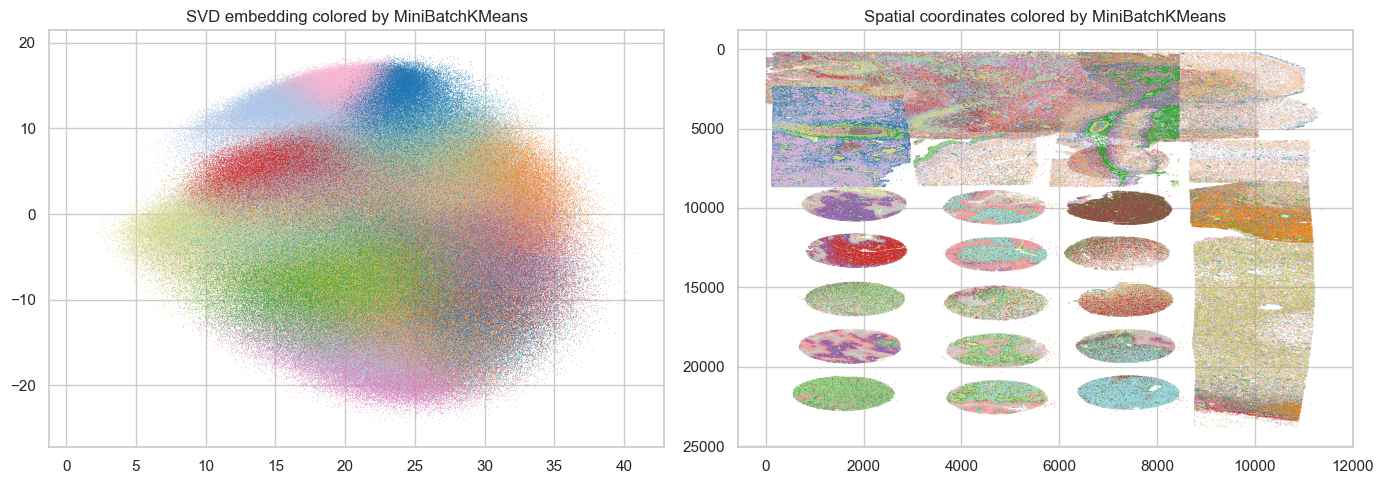

In [108]:
if RUN_PREPROCESSING and analysis_adata is not None:
    print("cluster sizes:")
    print(analysis_adata.obs["kmeans_cluster"].value_counts().sort_index())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(
        analysis_adata.obsm["X_svd_2d"][:, 0],
        analysis_adata.obsm["X_svd_2d"][:, 1],
        s=0.2,
        c=analysis_adata.obs["kmeans_cluster"].cat.codes.to_numpy(),
        cmap="tab20",
        linewidths=0,
    )
    axes[0].set_title("SVD embedding colored by MiniBatchKMeans")

    axes[1].scatter(
        analysis_adata.obsm["spatial"][:, 0],
        analysis_adata.obsm["spatial"][:, 1],
        s=0.2,
        c=analysis_adata.obs["kmeans_cluster"].cat.codes.to_numpy(),
        cmap="tab20",
        linewidths=0,
    )
    axes[1].set_title("Spatial coordinates colored by MiniBatchKMeans")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print("No preprocessing/clustering results to plot")


## Write and reload

The expression matrix stays sparse in the written `.h5ad`.

You can write:

- the raw combined object
- the per-sample objects
- the processed/clustering-ready analysis object


In [109]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PER_SAMPLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if WRITE_PER_SAMPLE_OUTPUTS:
    for sample_id, adata_one in per_sample_adatas.items():
        out_path = PER_SAMPLE_OUTPUT_DIR / f"{sample_id.lower()}.h5ad"
        adata_one.write_h5ad(out_path)
        print(f"Wrote per-sample: {out_path}")
else:
    print("WRITE_PER_SAMPLE_OUTPUTS is False")

if WRITE_COMBINED_OUTPUT:
    adata.write_h5ad(COMBINED_OUTPUT_PATH)
    print(f"Wrote combined: {COMBINED_OUTPUT_PATH}")
else:
    print("WRITE_COMBINED_OUTPUT is False")
    print(f"Planned combined output: {COMBINED_OUTPUT_PATH}")

if WRITE_ANALYSIS_OUTPUT:
    if analysis_adata is None:
        raise RuntimeError("analysis_adata is not available; run preprocessing first")
    analysis_adata.write_h5ad(ANALYSIS_OUTPUT_PATH)
    print(f"Wrote analysis: {ANALYSIS_OUTPUT_PATH}")
else:
    print("WRITE_ANALYSIS_OUTPUT is False")
    print(f"Planned analysis output: {ANALYSIS_OUTPUT_PATH}")


Wrote per-sample: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/per_sample/s1.h5ad
Wrote per-sample: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/per_sample/s2.h5ad
Wrote per-sample: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/per_sample/s5.h5ad
Wrote per-sample: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/per_sample/s6.h5ad
Wrote per-sample: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/per_sample/snu21.h5ad
Wrote per-sample: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/per_sample/snu33.h5ad
Wrote combined: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpace

In [110]:
if RELOAD_COMBINED_OUTPUT and COMBINED_OUTPUT_PATH.exists():
    adata_reloaded = ad.read_h5ad(COMBINED_OUTPUT_PATH)
    print(adata_reloaded)
    print("reloaded X format:", type(adata_reloaded.X))
else:
    adata_reloaded = None
    print("Reload skipped")


AnnData object with n_obs × n_vars = 1181985 × 348
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_id_original', 'dataset_id', 'sample_id', 'section_id', 'run_name', 'panel_name', 'preservation_method', 'source_sample', 'detected_genes', 'raw_total_counts'
    var: 'feature_id', 'feature_name', 'feature_type', 'genome'
    uns: 'experiment', 'metrics_summary'
    obsm: 'spatial'
reloaded X format: <class 'scipy.sparse._csr.csr_matrix'>


In [111]:
karospace_summary = {
    "sample_ids": selected_samples,
    "combined_output_path": str(COMBINED_OUTPUT_PATH),
    "analysis_output_path": str(ANALYSIS_OUTPUT_PATH),
    "section_key": "section_id",
    "sample_key": "sample_id",
    "spatial_key": "obsm['spatial']",
    "feature_filter": "Gene Expression only" if not INCLUDE_CONTROL_FEATURES else "includes control features",
    "candidate_color_columns": [
        "sample_id",
        "transcript_counts",
        "cell_area",
        "nucleus_area",
        "preservation_method",
        "panel_name",
    ],
}

print(json.dumps(karospace_summary, indent=2))


{
  "sample_ids": [
    "S1",
    "S2",
    "S5",
    "S6",
    "SNU21",
    "SNU33"
  ],
  "combined_output_path": "/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/glioblastoma-xenium-combined.h5ad",
  "analysis_output_path": "/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/glioblastoma-xenium/glioblastoma-xenium-combined-analysis.h5ad",
  "section_key": "section_id",
  "sample_key": "sample_id",
  "spatial_key": "obsm['spatial']",
  "feature_filter": "Gene Expression only",
  "candidate_color_columns": [
    "sample_id",
    "transcript_counts",
    "cell_area",
    "nucleus_area",
    "preservation_method",
    "panel_name"
  ]
}


In [114]:
analysis_adata.obs

,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,cell_id_original,dataset_id,sample_id,section_id,run_name,panel_name,preservation_method,source_sample,detected_genes,raw_total_counts,kmeans_cluster
cell_id,,,,,,,,,,,,,,,,,,,,,
S1__aaabafci-1,1095.969971,849.029480,202,0,0,0,0,202,675.853638,31.925470,aaabafci-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1,69,202.0,21
S1__aaabkgdi-1,1106.786377,834.867310,201,0,0,0,0,201,335.601257,37.344219,aaabkgdi-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1,62,201.0,21
S1__aaaejplh-1,1122.369507,840.919983,286,0,0,0,0,286,580.077209,48.001095,aaaejplh-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1,72,286.0,21
S1__aaafabdf-1,1120.727417,864.147949,100,0,0,0,0,100,445.105164,22.081408,aaafabdf-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1,44,100.0,14
S1__aaafgpec-1,1162.051514,849.963135,70,0,0,0,0,70,176.877045,11.740625,aaafgpec-1,glioblastoma-xenium,S1,S1_21_083_1,230810,hBrain_348g,ffpe,S1,45,70.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SNU33__oinmgkem-1,8360.121094,4305.709961,306,0,0,0,0,306,365.855957,26.777657,oinmgkem-1,glioblastoma-xenium,SNU33,SNU33_21-109,20231030,hBrain_348g,ffpe,SNU33,93,306.0,15
SNU33__oinmkaja-1,8382.600586,4312.125000,378,0,0,0,0,378,422.527039,16.572344,oinmkaja-1,glioblastoma-xenium,SNU33,SNU33_21-109,20231030,hBrain_348g,ffpe,SNU33,88,378.0,15
SNU33__oinmlocc-1,8434.368164,4302.373535,349,0,0,0,0,349,432.506592,28.132345,oinmlocc-1,glioblastoma-xenium,SNU33,SNU33_21-109,20231030,hBrain_348g,ffpe,SNU33,104,349.0,15


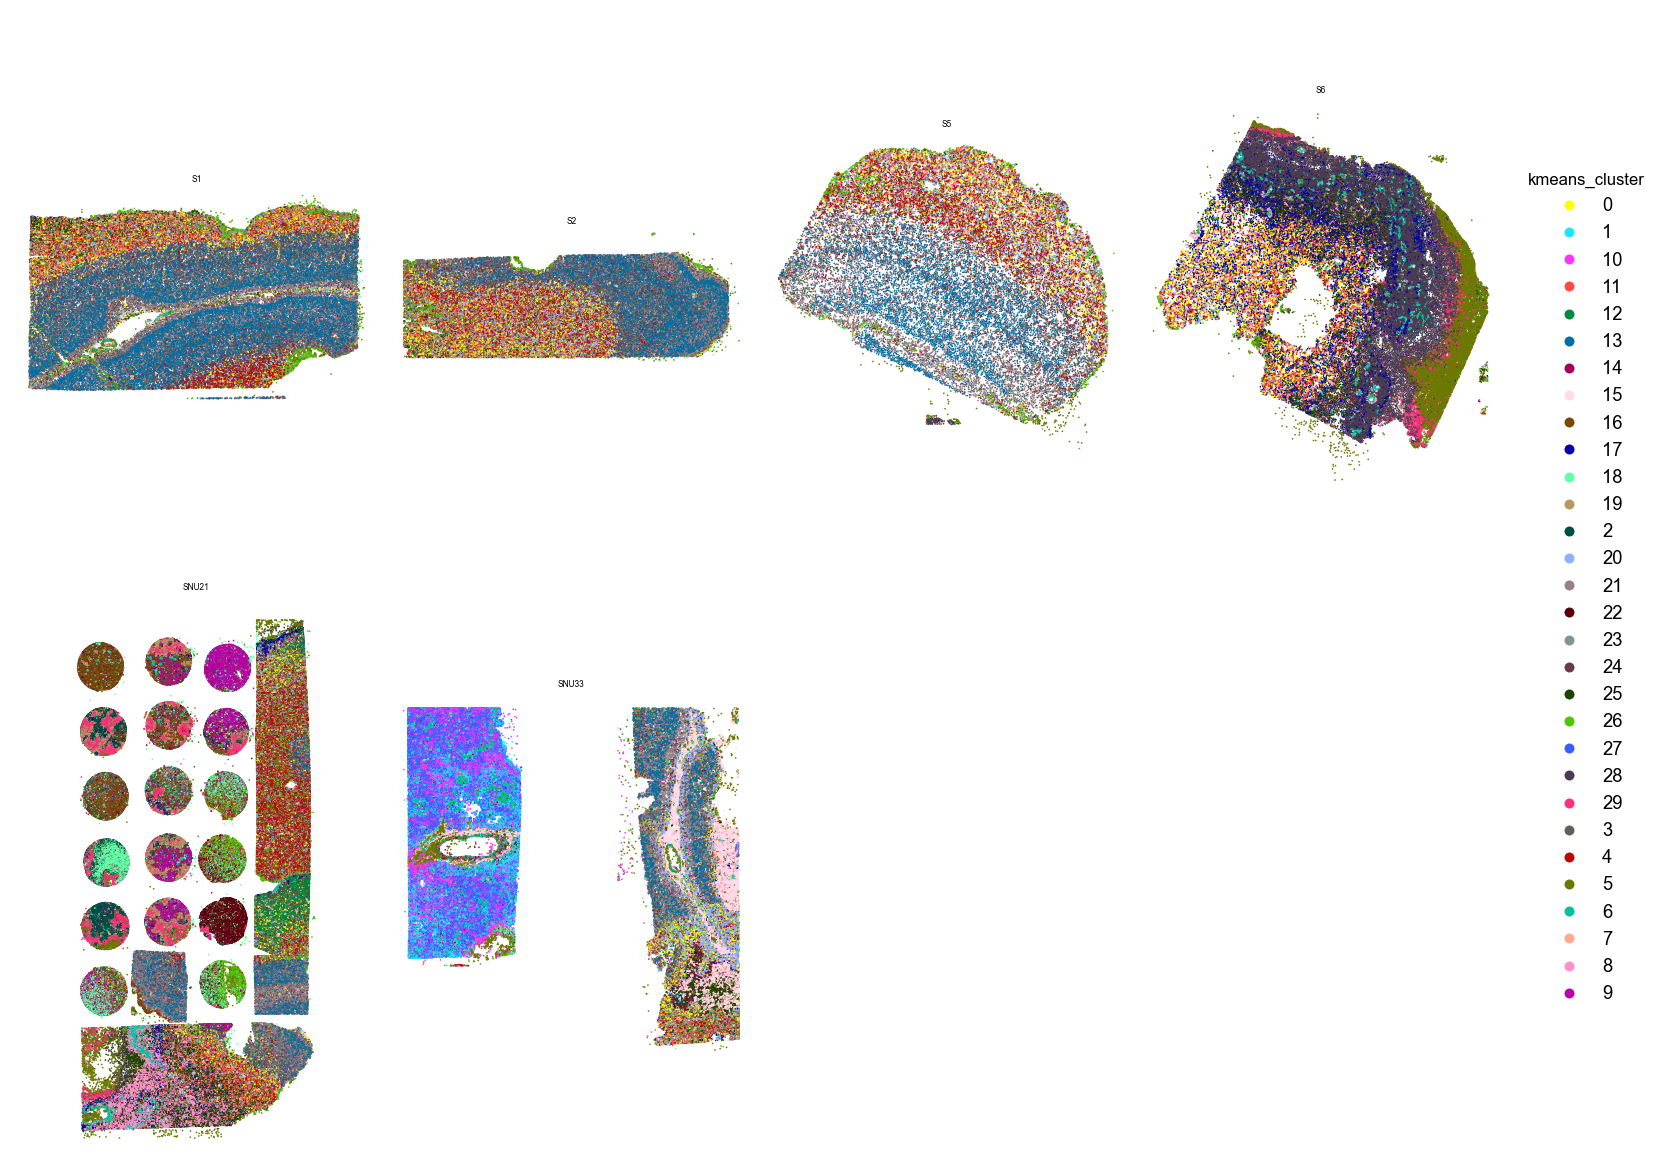

In [113]:
import sys
sys.path.append("/Users/chrislangseth/work/karolinska_institutet/projects/BaloMS/")
from utils import spatial_utils

spatial_utils.plot_spatial_compact_fast(
    analysis_adata,
    color="kmeans_cluster",
    groupby="sample_id",
    spot_size=1,
    cols=4,
    height=10,
    background="white",
    dpi=120,
)
